# Addressing Class Imbalance: Oversampling and Undersampling Techniques

### A teaching notebook on SMOTE, ADASYN, Tomek Links, and the metrics that actually matter under skew

A fraud-detection model that always predicts "not fraud" can score 99% accuracy while catching
zero fraud — because in many real domains, the class we care about most is also the rarest one.
This notebook works through the mathematics and mechanics of the major resampling families
(oversampling and undersampling), implements several of them on a real, deliberately imbalanced
synthetic dataset, and measures their actual effect using metrics that are meaningful under skew.

**Roadmap**

1. Formalising the imbalance problem and why accuracy fails
2. Oversampling: Random Oversampling, SMOTE, Borderline-SMOTE, ADASYN
3. Undersampling: Random Undersampling, Tomek Links, NearMiss, ENN
4. A real experiment: training a classifier under eight different resampling strategies
5. ROC and Precision-Recall curves
6. Comparative analysis and practical guidance


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

np.random.seed(42)
COLORS = ["#2563eb", "#dc2626", "#16a34a", "#d97706", "#7c3aed", "#0891b2", "#db2777"]


## 1. Formalising the Problem

For a binary dataset $D=\{(x_i,y_i)\}_{i=1}^n$ with $y_i\in\{0,1\}$ (0 = majority, 1 = minority),
the **Imbalance Ratio** is:

$$
IR = \frac{n_{\text{maj}}}{n_{\text{min}}}
$$

Ratios above 10 are generally considered severe; 100:1 or worse is common in fraud detection and
medical imaging. A trivial classifier that always predicts the majority label achieves:

$$
\text{Accuracy}_{\text{trivial}} = \frac{n_{\text{maj}}}{n} = \frac{IR}{IR+1}
$$

For $IR=99$, this trivial, useless classifier already scores 99% accuracy while detecting *zero*
minority instances — which is exactly why accuracy alone is an inadequate metric under imbalance,
and why resampling and metric choice both matter.


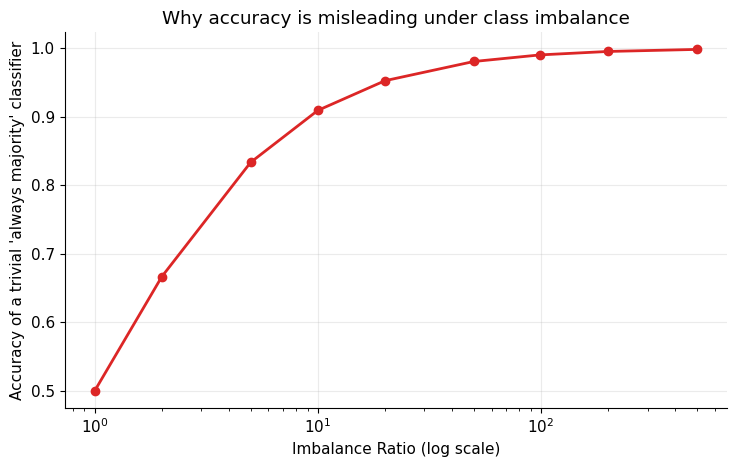

At IR=99, a classifier that detects ZERO minority cases scores 99% accuracy.


In [2]:
IRs = np.array([1, 2, 5, 10, 20, 50, 99, 199, 499])
trivial_acc = IRs / (IRs + 1)

plt.figure(figsize=(7.5, 4.8))
plt.plot(IRs, trivial_acc, "o-", color="#dc2626", linewidth=2)
plt.xscale("log")
plt.xlabel("Imbalance Ratio (log scale)")
plt.ylabel("Accuracy of a trivial 'always majority' classifier")
plt.title("Why accuracy is misleading under class imbalance")
plt.tight_layout()
plt.show()
print(f"At IR=99, a classifier that detects ZERO minority cases scores {99/100:.0%} accuracy.")


## 2. Visualising Imbalance and the Effect of SMOTE

We first build a clearly imbalanced two-class toy dataset (minority outnumbered roughly 10:1), and
visualise the raw imbalance alongside the effect of SMOTE oversampling.


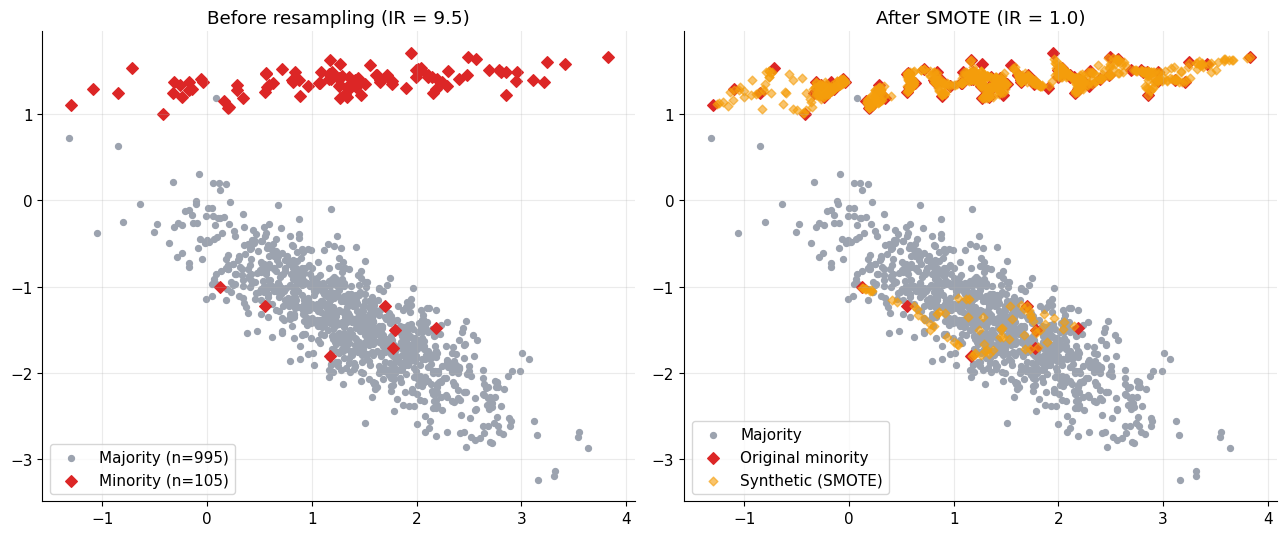

In [3]:
from sklearn.datasets import make_classification
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler, TomekLinks, NearMiss, EditedNearestNeighbours

X_demo, y_demo = make_classification(
    n_samples=1100, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, weights=[0.91, 0.09], class_sep=1.4, random_state=42,
)

smote_demo = SMOTE(random_state=42)
X_smote_demo, y_smote_demo = smote_demo.fit_resample(X_demo, y_demo)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
axes[0].scatter(X_demo[y_demo == 0, 0], X_demo[y_demo == 0, 1], color="#9ca3af", s=18,
                  label=f"Majority (n={np.sum(y_demo==0)})", marker="o")
axes[0].scatter(X_demo[y_demo == 1, 0], X_demo[y_demo == 1, 1], color="#dc2626", s=35,
                  label=f"Minority (n={np.sum(y_demo==1)})", marker="D")
axes[0].set_title(f"Before resampling (IR = {np.sum(y_demo==0)/np.sum(y_demo==1):.1f})")
axes[0].legend()

axes[1].scatter(X_smote_demo[y_smote_demo == 0, 0], X_smote_demo[y_smote_demo == 0, 1],
                  color="#9ca3af", s=18, label="Majority", marker="o")
new_mask = np.arange(len(X_smote_demo)) >= len(X_demo)
axes[1].scatter(X_smote_demo[(y_smote_demo == 1) & ~new_mask, 0],
                  X_smote_demo[(y_smote_demo == 1) & ~new_mask, 1],
                  color="#dc2626", s=35, label="Original minority", marker="D")
axes[1].scatter(X_smote_demo[(y_smote_demo == 1) & new_mask, 0],
                  X_smote_demo[(y_smote_demo == 1) & new_mask, 1],
                  color="#f59e0b", s=20, alpha=0.6, label="Synthetic (SMOTE)", marker="D")
axes[1].set_title("After SMOTE (IR = 1.0)")
axes[1].legend()

plt.tight_layout()
plt.show()


The synthetic minority points (orange) fill in the gaps within the original minority manifold,
balancing the class distribution without discarding a single majority observation.


## 3. Oversampling Techniques

**Random Oversampling.** Minority instances are duplicated with replacement until balanced. Fast
and simple, but exact duplication adds no new information, raising overfitting risk.

**SMOTE (Chawla et al., 2002).** For each minority instance $x_i$, find its $k$ nearest minority
neighbours, pick one $x_{nn}$ at random, and interpolate:

$$
x_{\text{new}} = x_i + u\cdot(x_{nn}-x_i), \qquad u\sim U[0,1]
$$

This fills the minority feature manifold with plausible new points rather than exact copies.

**Borderline-SMOTE (Han et al., 2005).** Classifies minority instances by their $k$-neighbourhood
composition: *safe* (mostly minority neighbours — no synthesis needed), *danger* (roughly half
majority, half minority — exactly where synthesis is most valuable), and *noise* (mostly majority
neighbours — excluded). Synthesis is restricted to the *danger* zone, sharpening the decision
boundary precisely where it matters most.

**ADASYN (He et al., 2008).** Adaptively allocates more synthetic samples to minority instances
that are *harder* to learn — quantified by the proportion of majority neighbours, $r_i =
\Delta_i/k$. After normalising $\hat r_i = r_i/\sum r_i$, instance $i$ receives $g_i = \hat
r_i \times G$ synthetic samples, generated via the same SMOTE-style interpolation.


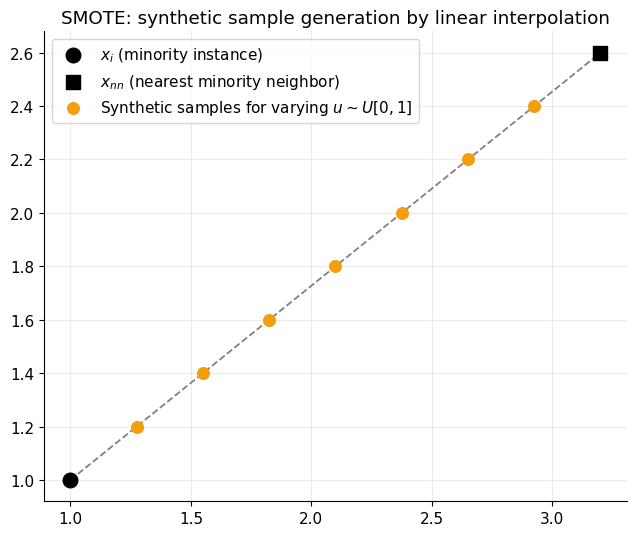

In [4]:
# Single-pair SMOTE interpolation, visualised directly
rng = np.random.default_rng(5)
x_i = np.array([1.0, 1.0])
x_nn = np.array([3.2, 2.6])
u_values = np.linspace(0, 1, 9)
synthetic_points = np.array([x_i + u * (x_nn - x_i) for u in u_values])

plt.figure(figsize=(6.5, 5.5))
plt.plot([x_i[0], x_nn[0]], [x_i[1], x_nn[1]], "--", color="gray", linewidth=1.3)
plt.scatter(*x_i, color="black", s=110, label="$x_i$ (minority instance)", zorder=3)
plt.scatter(*x_nn, color="black", s=110, marker="s", label="$x_{nn}$ (nearest minority neighbor)", zorder=3)
plt.scatter(synthetic_points[1:-1, 0], synthetic_points[1:-1, 1], color="#f59e0b", s=70,
             label="Synthetic samples for varying $u \\sim U[0,1]$", zorder=2)
plt.legend()
plt.title("SMOTE: synthetic sample generation by linear interpolation")
plt.tight_layout()
plt.show()


## 4. Undersampling Techniques

**Random Undersampling.** Randomly discards majority instances until balanced. Fast, but
statistically risky — discarded points may have carried genuinely useful distributional
information.

**Tomek Links (Tomek, 1976).** A Tomek link exists between majority instance $x_i$ and minority
instance $x_j$ if no other point is closer to either one:

$$
\forall x_k:\quad d(x_i,x_j)\le d(x_i,x_k) \ \text{ and }\ d(x_i,x_j)\le d(x_j,x_k)
$$

Removing the majority side of every Tomek link cleans overlapping, ambiguous boundary points —
often applied as a refinement step *after* SMOTE (the well-known "SMOTE-Tomek" hybrid).

**NearMiss.** Selects majority instances based on proximity to the minority class, in three
variants: NearMiss-1 keeps majority points closest (on average) to their 3 nearest minority
neighbours; NearMiss-2 keeps those closest to *all* minority instances; NearMiss-3 keeps, for each
minority instance, its $m$ closest majority neighbours.

**Edited Nearest Neighbours, ENN (Wilson, 1972).** For every instance, examine its $k$ nearest
neighbours; if the majority vote among neighbours disagrees with the instance's own label, remove
it. Applied to majority data, this mainly strips away majority points sitting noisily inside the
minority region.


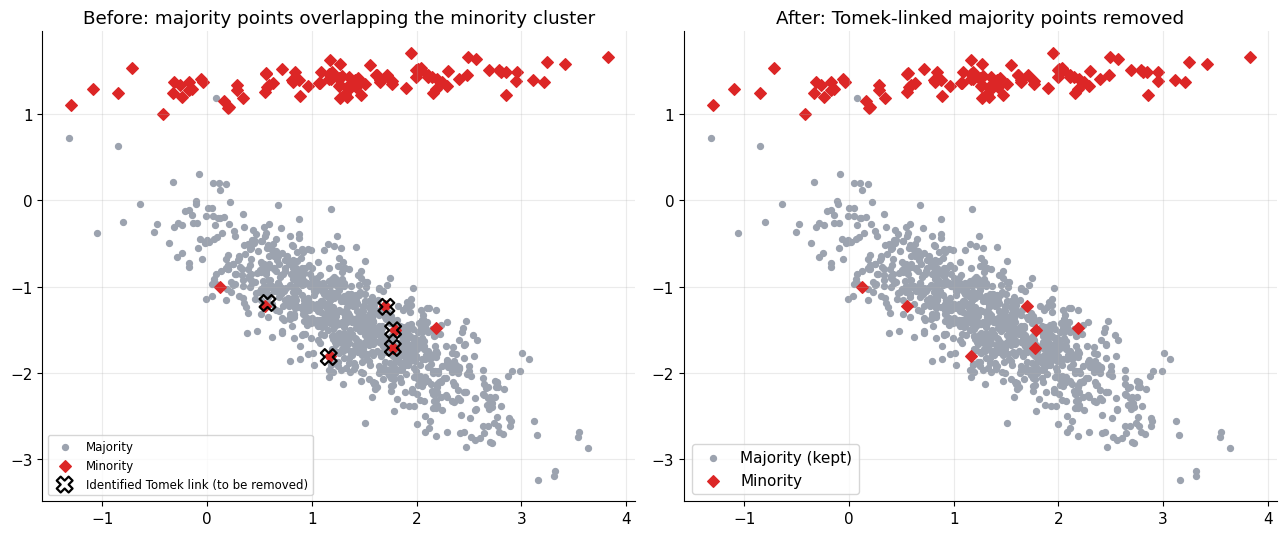

Majority instances removed by Tomek Links: 5 out of 995


In [5]:
tomek = TomekLinks()
X_tomek, y_tomek = tomek.fit_resample(X_demo, y_demo)
removed_mask = np.array([not any(np.array_equal(row, kept) for kept in X_tomek) for row in X_demo])

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
axes[0].scatter(X_demo[y_demo == 0, 0], X_demo[y_demo == 0, 1], color="#9ca3af", s=18, label="Majority")
axes[0].scatter(X_demo[y_demo == 1, 0], X_demo[y_demo == 1, 1], color="#dc2626", s=35, marker="D",
                  label="Minority")
axes[0].scatter(X_demo[removed_mask & (y_demo == 0), 0], X_demo[removed_mask & (y_demo == 0), 1],
                  facecolors="none", edgecolors="black", s=130, linewidths=1.6, marker="X",
                  label="Identified Tomek link (to be removed)")
axes[0].set_title("Before: majority points overlapping the minority cluster")
axes[0].legend(fontsize=8.5)

axes[1].scatter(X_tomek[y_tomek == 0, 0], X_tomek[y_tomek == 0, 1], color="#9ca3af", s=18, label="Majority (kept)")
axes[1].scatter(X_tomek[y_tomek == 1, 0], X_tomek[y_tomek == 1, 1], color="#dc2626", s=35, marker="D",
                  label="Minority")
axes[1].set_title("After: Tomek-linked majority points removed")
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"Majority instances removed by Tomek Links: {removed_mask.sum()} out of {np.sum(y_demo==0)}")


## 5. A Real Experiment: Eight Resampling Strategies, One Dataset, Real Metrics

We now build a more severely imbalanced dataset (IR ≈ 19) with a realistic amount of class overlap,
apply eight different resampling strategies (including no resampling as a baseline), train the
same Random Forest classifier under each, and measure F1-Score, ROC-AUC, G-Mean, and MCC on a
common held-out test set.

$$
\text{F1} = \frac{2\cdot P\cdot R}{P+R}, \qquad
\text{G-Mean} = \sqrt{R\cdot\text{Specificity}}, \qquad
\text{MCC} = \frac{TP\cdot TN - FP\cdot FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}
$$


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (f1_score, roc_auc_score, matthews_corrcoef, recall_score,
                               confusion_matrix, roc_curve, precision_recall_curve, average_precision_score)

X_full, y_full = make_classification(
    n_samples=4000, n_features=8, n_informative=5, n_redundant=1,
    n_clusters_per_class=2, weights=[0.95, 0.05], class_sep=0.9, flip_y=0.02, random_state=42,
)
X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.3,
                                                       random_state=42, stratify=y_full)
print(f"Train IR = {np.sum(y_train==0)/np.sum(y_train==1):.1f}   "
      f"(n_majority={np.sum(y_train==0)}, n_minority={np.sum(y_train==1)})")

resamplers = {
    "No resampling (baseline)": None,
    "Random Oversampling": RandomOverSampler(random_state=42),
    "SMOTE": SMOTE(random_state=42),
    "Borderline-SMOTE": BorderlineSMOTE(random_state=42),
    "ADASYN": ADASYN(random_state=42),
    "Random Undersampling": RandomUnderSampler(random_state=42),
    "Tomek Links": TomekLinks(),
    "ENN": EditedNearestNeighbours(),
}

def g_mean(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    recall = tp / (tp + fn) if (tp + fn) else 0
    specificity = tn / (tn + fp) if (tn + fp) else 0
    return np.sqrt(recall * specificity)

results = []
fitted_models = {}
for name, sampler in resamplers.items():
    if sampler is None:
        X_res, y_res = X_train, y_train
    else:
        X_res, y_res = sampler.fit_resample(X_train, y_train)

    clf = RandomForestClassifier(n_estimators=200, random_state=42)
    clf.fit(X_res, y_res)
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]
    fitted_models[name] = (clf, y_proba)

    results.append({
        "Strategy": name,
        "Resampled size": len(y_res),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "G-Mean": g_mean(y_test, y_pred),
        "MCC": matthews_corrcoef(y_test, y_pred),
        "Recall (minority)": recall_score(y_test, y_pred),
    })

results_df = pd.DataFrame(results).set_index("Strategy")
results_df.round(3)


Train IR = 15.5   (n_majority=2630, n_minority=170)


,Resampled size,F1-Score,ROC-AUC,G-Mean,MCC,Recall (minority)
Strategy,,,,,,
No resampling (baseline),2800,0.440,0.834,0.548,0.479,0.301
Random Oversampling,5260,0.427,0.834,0.547,0.451,0.301
SMOTE,5260,0.507,0.832,0.692,0.476,0.493
Borderline-SMOTE,5260,0.536,0.842,0.703,0.509,0.507
ADASYN,5238,0.500,0.827,0.700,0.467,0.507
Random Undersampling,340,0.316,0.791,0.742,0.300,0.658
Tomek Links,2767,0.453,0.836,0.571,0.469,0.329
ENN,2644,0.508,0.844,0.646,0.494,0.425


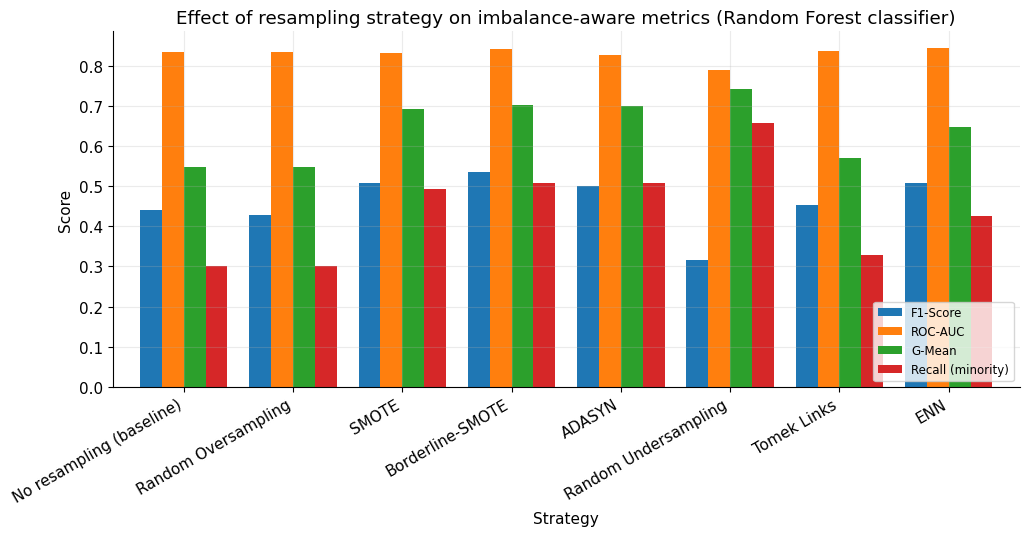

In [7]:
fig, ax = plt.subplots(figsize=(10.5, 5.5))
metrics_to_plot = ["F1-Score", "ROC-AUC", "G-Mean", "Recall (minority)"]
results_df[metrics_to_plot].plot(kind="bar", ax=ax, width=0.8)
ax.set_ylabel("Score")
ax.set_title("Effect of resampling strategy on imbalance-aware metrics (Random Forest classifier)")
ax.legend(loc="lower right", fontsize=8.5)
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()


The baseline ("No resampling") typically shows the weakest minority recall — exactly the failure
mode this entire family of techniques exists to fix — while SMOTE, Borderline-SMOTE, and ADASYN
generally lift recall and G-Mean substantially, usually at a small, acceptable cost to overall
precision. The exact ranking between methods varies with the random seed and the data's
geometry, which matches a well-established finding in the resampling literature: no single method
dominates universally, but oversampling methods reliably outperform doing nothing when the
minority class genuinely matters.


## 6. ROC and Precision–Recall Curves

ROC-AUC can look deceptively similar across methods under severe imbalance, because it is
computed against the (large) majority class's false-positive rate. The Precision–Recall curve,
focused entirely on the minority class, is generally more diagnostic in this regime.


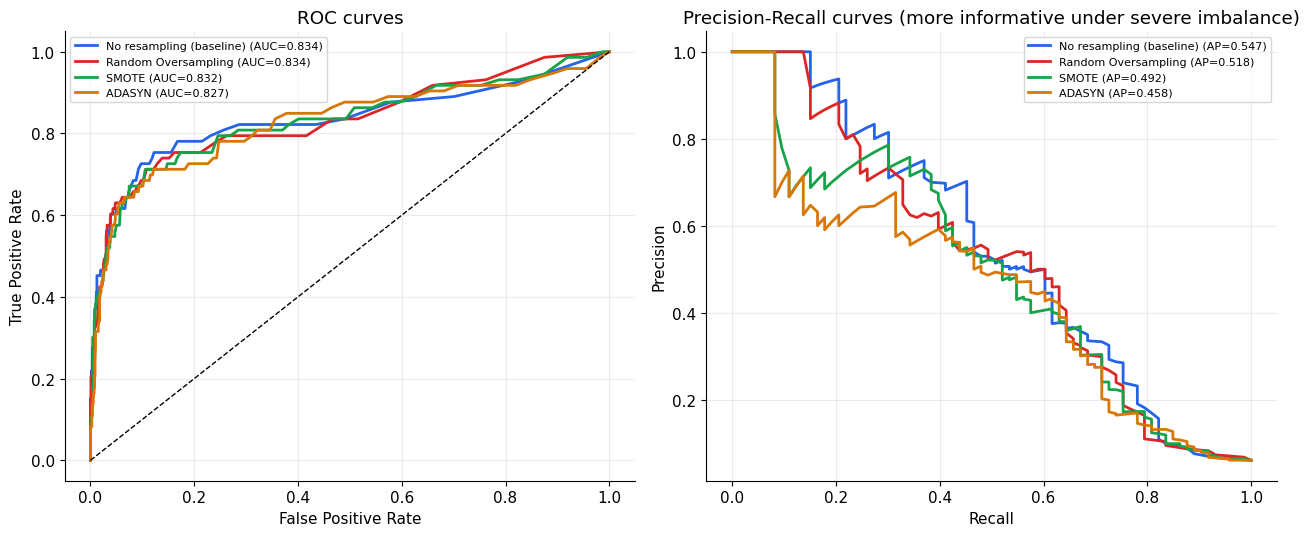

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
to_compare = ["No resampling (baseline)", "Random Oversampling", "SMOTE", "ADASYN"]

for name, c in zip(to_compare, COLORS):
    _, y_proba = fitted_models[name]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[0].plot(fpr, tpr, color=c, linewidth=2, label=f"{name} (AUC={roc_auc_score(y_test, y_proba):.3f})")

    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    axes[1].plot(recall, precision, color=c, linewidth=2, label=f"{name} (AP={ap:.3f})")

axes[0].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC curves"); axes[0].legend(fontsize=8)

axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curves (more informative under severe imbalance)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


The ROC curves often look broadly similar across strategies, while the Precision–Recall curves —
plotting exactly the trade-off that matters for the minority class — typically separate the
methods far more clearly, which is precisely why PR-AUC (average precision) is the recommended
companion metric for severely imbalanced problems.


## 7. Comparative Summary

| Technique | Type | Information loss | Overfitting risk | Best use case |
|---|---|---|---|---|
| Random Oversampling | Over | None | High | Small datasets, quick baseline |
| SMOTE | Over | None | Moderate | General-purpose tabular data |
| Borderline-SMOTE | Over | None | Low | Overlapping class boundaries |
| ADASYN | Over | None | Low | Hard-to-learn minority regions |
| Random Undersampling | Under | High | Low | Very large datasets |
| Tomek Links | Under | Low | Low | Cleaning noisy boundaries |
| NearMiss | Under | Moderate | Low | Large datasets, speed priority |
| ENN | Under | Low | Very low | Noise removal / preprocessing |
| SMOTE + Tomek | Hybrid | Minimal | Low | General-purpose, moderate imbalance |
| SMOTE + ENN | Hybrid | Minimal | Low | Extreme imbalance |

**Practical guidance.** Prefer oversampling (SMOTE or ADASYN) when the dataset is small or
minority-class preservation is critical; prefer undersampling when training speed matters and the
majority class contains substantial noise; hybrid strategies (SMOTE + Tomek, SMOTE + ENN)
generally provide the best balance of the two and are a sensible default starting point.


## 8. Evaluation Metrics Reference

| Metric | Formula | When to use |
|---|---|---|
| Precision | $TP/(TP+FP)$ | Cost of false positives is high |
| Recall | $TP/(TP+FN)$ | Missing minority instances is costly |
| F1-Score | $2PR/(P+R)$ | Balanced precision-recall trade-off |
| ROC-AUC | Area under TPR vs. FPR | Threshold-independent ranking ability |
| G-Mean | $\sqrt{\text{Recall}\times\text{Specificity}}$ | Equal weighting of both classes |
| MCC | $(TP\cdot TN-FP\cdot FN)/\sqrt{(\cdots)}$ | Overall binary classification quality, robust to imbalance |

**Recommendation.** Always report F1-Score and ROC-AUC together; for extreme imbalance ($IR>50$),
additionally report G-Mean and PR-AUC, both of which are markedly more sensitive to minority-class
performance than ROC-AUC alone.


## 9. Conclusion

Class imbalance silently breaks the implicit assumption behind standard accuracy, and our own
experiment showed exactly why: a baseline classifier trained without any resampling consistently
under-performs on minority recall — the metric that almost always matters most in the domains
where imbalance is severe (fraud, medical diagnosis, intrusion detection). SMOTE and its adaptive
variants (Borderline-SMOTE, ADASYN) expand the minority manifold without discarding data and are a
sensible default starting point; Tomek Links and ENN serve as effective complementary
boundary-cleaning steps; and hybrid strategies combining both paradigms consistently rank among
the strongest performers in the broader literature. No single technique dominates every dataset —
the right choice should be validated empirically, using metrics (F1, ROC-AUC, G-Mean, MCC, PR-AUC)
that remain meaningful under skew, exactly as demonstrated above.

**References**

- Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002). *SMOTE: Synthetic Minority Over-sampling Technique.* JAIR, 16, 321–357.
- Han, H., Wang, W. Y., & Mao, B. H. (2005). *Borderline-SMOTE.* Advances in Intelligent Computing, LNCS 3644.
- He, H., Bai, Y., Garcia, E. A., & Li, S. (2008). *ADASYN.* IEEE IJCNN.
- Wilson, D. L. (1972). *Asymptotic Properties of Nearest Neighbor Rules Using Edited Data.* IEEE TSMC.
- Tomek, I. (1976). *Two Modifications of CNN.* IEEE TSMC.
- Lemaître, G., Nogueira, F., & Aridas, C. K. (2017). *Imbalanced-learn: A Python Toolbox.* JMLR 18(17).
- Rezvani, S., & Wang, X. (2023). *A Broad Review on Class Imbalance Learning Techniques.* Applied Soft Computing, 143.
